<a href="https://colab.research.google.com/github/JdogLloyd1/DeepLearning5888Project/blob/main/Code/Transfer%20Learning/VGGish_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
!pip install torch torchaudio librosa numpy pandas
!pip install torchvggish

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

SEED = 99
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ZIP_PATH = '/content/drive/MyDrive/ESCProjectDeepLearning5888DataDump/piczak_dataset.zip'
EXTRACT_DIR = '/content/piczak_dataset'
OUTPUT_DIR = '/content/drive/MyDrive/5888_Project/results/Phase1_Baseline'

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_DIR)

CSV_PATH = None
AUDIO_DIR = None

for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'esc50.csv' in files:
        CSV_PATH = os.path.join(root, 'esc50.csv')

    wav_files = [file_name for file_name in files if file_name.endswith('.wav')]
    if len(wav_files) > 0 and AUDIO_DIR is None:
        AUDIO_DIR = root

print('Dataset CSV:  ', CSV_PATH)
print('Audio folder: ', AUDIO_DIR)
print('Output folder:', OUTPUT_DIR)
print('Audio files:  ', len([file_name for file_name in os.listdir(AUDIO_DIR) if file_name.endswith('.wav')]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset CSV:   /content/piczak_dataset/esc50.csv
Audio folder:  /content/piczak_dataset/audio/audio
Output folder: /content/drive/MyDrive/5888_Project/results/Phase1_Baseline
Audio files:   2000


In [85]:
from torchvggish import vggish, vggish_input

In [86]:
import torch
import torchaudio
import pandas as pd
import os

class ESC50Dataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, audio_dir, fold, train=True):
        self.df = pd.read_csv(csv_file)
        if train:
            self.df = self.df[self.df['fold'] != fold]
        else:
            self.df = self.df[self.df['fold'] == fold]

        self.audio_dir = audio_dir
        self.resampler = torchaudio.transforms.Resample(44100, 16000)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])

        waveform, sr = torchaudio.load(file_path)

        # Convert to mono
        waveform = waveform.mean(dim=0, keepdim=True)

        # Resample to 16kHz
        waveform = self.resampler(waveform)

        label = row['target']
        return waveform.squeeze(0), label

```markdown
The `ESC50Dataset` class, as defined in cell `xEEQ-zTPJ6wW`, already implements the necessary logic for cross-validation partitioning. The `__init__` method takes a `fold` number and a `train` boolean argument:

- If `train` is `True`, it filters the DataFrame to include all data *except* the specified `fold` (`self.df = self.df[self.df['fold'] != fold]`). This creates the training set.
- If `train` is `False`, it filters the DataFrame to include *only* the specified `fold` (`self.df = self.df[self.df['fold'] == fold]`). This creates the testing set.

This confirms that the dataset class correctly supports dynamic partitioning for cross-validation.
```

## Implement 5-Fold Cross-Validation Loop

### Subtask:
Initialize data structures to store results, then iterate through folds 1 to 5, performing both 'Frozen VGGish' and 'Fine-tuned VGGish' experiments for each fold, and storing their epoch-wise training and testing metrics.


In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vggish_model = vggish()
vggish_model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [88]:
for param in vggish_model.parameters():
    param.requires_grad = False

In [89]:
def extract_embedding_frozen(vggish_model_instance, waveform):
    # The waveform from ESC50Dataset is already resampled to 16kHz.
    # vggish_input.waveform_to_examples expects a CPU tensor.
    waveform_cpu = waveform.cpu()

    # Convert waveform to VGGish input examples (log-mel spectrograms)
    # It expects a numpy array, so convert the tensor.
    vggish_examples = vggish_input.waveform_to_examples(waveform_cpu.numpy(), sample_rate=16000)

    # Move the processed examples to the device (cuda or cpu)
    vggish_examples = vggish_examples.to(device)

    # Use torch.no_grad() to prevent backpropagation through VGGish when frozen
    with torch.no_grad():
        embeddings = vggish_model_instance(vggish_examples)

    # embeddings will be (num_frames, 128) - perform mean pooling across frames
    return embeddings.mean(dim=0)

In [90]:
def extract_embedding_finetune(vggish_model_instance, waveform):
    # The waveform from ESC50Dataset is already resampled to 16kHz.
    waveform_cpu = waveform.cpu()

    # Convert waveform to VGGish input examples (log-mel spectrograms)
    vggish_examples = vggish_input.waveform_to_examples(waveform_cpu.numpy(), sample_rate=16000)

    # Move the processed examples to the device
    vggish_examples = vggish_examples.to(device)

    # No torch.no_grad() here, allowing gradients to flow for fine-tuning
    embeddings = vggish_model_instance(vggish_examples)

    # embeddings will be (num_frames, 128) - perform mean pooling across frames
    return embeddings.mean(dim=0)

In [91]:
import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 50)
        )

    def forward(self, x):
        return self.net(x)

In [92]:
import time

def train_and_evaluate(vggish_model_instance, classifier_model_instance, optimizer, criterion,
                           train_loader, test_loader, epochs, device, embedding_extractor_func,
                           experiment_name_prefix, save_path_prefix):

    # Move VGGish post-processing tensors to the correct device
    if vggish_model_instance.postprocess:
        vggish_model_instance.pproc._pca_matrix = vggish_model_instance.pproc._pca_matrix.to(device)
        vggish_model_instance.pproc._pca_means = vggish_model_instance.pproc._pca_means.to(device)

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    print(f'Starting Training ({experiment_name_prefix})...')
    for epoch in range(epochs):
        classifier_model_instance.train()
        # If VGGish is part of the optimizer (fine-tuning), it will also be in train mode.
        # If frozen, it remains in eval mode implicitly as its params are not updated.
        total_train_loss = 0
        correct_train = 0
        total_train_samples = 0

        for waveforms, labels in train_loader:
            batch_embeddings = []
            for wf in waveforms:
                emb = embedding_extractor_func(vggish_model_instance, wf)
                batch_embeddings.append(emb)

            batch_embeddings = torch.stack(batch_embeddings).to(device)
            labels = labels.to(device)

            outputs = classifier_model_instance(batch_embeddings)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train_samples += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = total_train_loss / total_train_samples
        train_accuracy = 100 * correct_train / total_train_samples
        print(f'Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        classifier_model_instance.eval()
        # VGGish also in eval mode for evaluation
        vggish_model_instance.eval()
        total_test_loss = 0
        correct_test = 0
        total_test_samples = 0

        with torch.no_grad():
            for waveforms, labels in test_loader:
                batch_embeddings = []
                for wf in waveforms:
                    emb = embedding_extractor_func(vggish_model_instance, wf)
                    batch_embeddings.append(emb)

                batch_embeddings = torch.stack(batch_embeddings).to(device)
                labels = labels.to(device)

                outputs = classifier_model_instance(batch_embeddings)
                loss = criterion(outputs, labels)

                total_test_loss += loss.item() * waveforms.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_test_samples += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        avg_test_loss = total_test_loss / total_test_samples
        test_accuracy = 100 * correct_test / total_test_samples
        print(f'Epoch {epoch + 1}/{epochs}, Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

    # Final evaluation after training
    print(f'\nStarting Final Evaluation ({experiment_name_prefix})...')
    classifier_model_instance.eval()
    vggish_model_instance.eval()
    total_test_loss = 0
    correct_test = 0
    total_test_samples = 0
    start_time = time.time()

    with torch.no_grad():
        for waveforms, labels in test_loader:
            batch_embeddings = []
            for wf in waveforms:
                emb = embedding_extractor_func(vggish_model_instance, wf)
                batch_embeddings.append(emb)

            batch_embeddings = torch.stack(batch_embeddings).to(device)
            labels = labels.to(device)

            outputs = classifier_model_instance(batch_embeddings)
            loss = criterion(outputs, labels)

            total_test_loss += loss.item() * waveforms.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test_samples += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    end_time = time.time()

    avg_test_loss = total_test_loss / total_test_samples
    test_accuracy = 100 * correct_test / total_test_samples
    evaluation_time = end_time - start_time

    print(f'\nFinal Test Loss ({experiment_name_prefix}): {avg_test_loss:.4f}, Final Test Accuracy ({experiment_name_prefix}): {test_accuracy:.2f}%')
    print(f'Final Evaluation prediction time ({experiment_name_prefix}): {evaluation_time:.2f} seconds')

    # Save results
    save_results(train_losses, train_accuracies, test_losses, test_accuracies, OUTPUT_DIR, filename_prefix=save_path_prefix)

    return train_losses, train_accuracies, test_losses, test_accuracies

# --- Frozen VGGish Experiment Setup and Run ---
model_frozen_vggish = Classifier().to(device)
optimizer_frozen_vggish = torch.optim.Adam(model_frozen_vggish.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Define training parameters
epochs = 50  # You can adjust this value
batch_size = 32 # You can adjust this value

# Assuming CSV_PATH and AUDIO_DIR are defined from previous cells
# Create datasets
train_dataset = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=5, train=True)
test_dataset = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=5, train=False)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Ensure the global vggish_model is set to eval and frozen for this experiment
vggish_model.eval()
for param in vggish_model.parameters():
    param.requires_grad = False


frozen_vggish_train_losses, frozen_vggish_train_accuracies, frozen_vggish_test_losses, frozen_vggish_test_accuracies = \
    train_and_evaluate(vggish_model, model_frozen_vggish, optimizer_frozen_vggish, criterion,
                       train_loader, test_loader, epochs, device, extract_embedding_frozen,
                       "Frozen VGGish", "frozen_vggish_training_results")

Starting Training (Frozen VGGish)...
Epoch 1/50, Train Loss: 21.3154, Train Accuracy: 6.62%
Epoch 1/50, Test Loss: 3.5987, Test Accuracy: 14.75%
Epoch 2/50, Train Loss: 3.4251, Train Accuracy: 15.50%
Epoch 2/50, Test Loss: 3.2247, Test Accuracy: 19.25%
Epoch 3/50, Train Loss: 3.1421, Train Accuracy: 23.75%
Epoch 3/50, Test Loss: 3.0398, Test Accuracy: 28.25%
Epoch 4/50, Train Loss: 2.9757, Train Accuracy: 26.81%
Epoch 4/50, Test Loss: 2.7927, Test Accuracy: 31.50%
Epoch 5/50, Train Loss: 2.9151, Train Accuracy: 28.19%
Epoch 5/50, Test Loss: 2.8728, Test Accuracy: 31.00%
Epoch 6/50, Train Loss: 2.7096, Train Accuracy: 31.75%
Epoch 6/50, Test Loss: 2.7048, Test Accuracy: 34.25%
Epoch 7/50, Train Loss: 2.4496, Train Accuracy: 37.25%
Epoch 7/50, Test Loss: 2.4771, Test Accuracy: 40.00%
Epoch 8/50, Train Loss: 2.3582, Train Accuracy: 38.75%
Epoch 8/50, Test Loss: 2.2914, Test Accuracy: 40.50%
Epoch 9/50, Train Loss: 2.2401, Train Accuracy: 39.88%
Epoch 9/50, Test Loss: 2.1879, Test Accuracy

In [93]:
# --- Fine-tuned VGGish Experiment Setup and Run ---
print('\n' + '='*50 + '\n')
print('Starting Fine-tuned VGGish Experiment')
print('='*50 + '\n')

# Create a new VGGish model instance for fine-tuning
vggish_model_finetune = vggish()
vggish_model_finetune.to(device)

# Ensure all parameters in this new VGGish model are trainable
for param in vggish_model_finetune.parameters():
    param.requires_grad = True

# Create a new Classifier instance for fine-tuning
model_finetuned_vggish = Classifier().to(device)

# Optimizer for both VGGish and Classifier parameters
# We'll use a smaller learning rate for VGGish if needed, but for simplicity, applying to all.
optimizer_finetuned_vggish = torch.optim.Adam(list(vggish_model_finetune.parameters()) + list(model_finetuned_vggish.parameters()), lr=1e-4)

# Reuse the same criterion, epochs, batch_size, and data loaders

finetuned_vggish_train_losses, finetuned_vggish_train_accuracies, finetuned_vggish_test_losses, finetuned_vggish_test_accuracies = \
    train_and_evaluate(vggish_model_finetune, model_finetuned_vggish, optimizer_finetuned_vggish, criterion,
                       train_loader, test_loader, epochs, device, extract_embedding_finetune,
                       "Fine-tuned VGGish", "finetuned_vggish_training_results")



Starting Fine-tuned VGGish Experiment

Starting Training (Fine-tuned VGGish)...
Epoch 1/50, Train Loss: 58.8984, Train Accuracy: 2.25%
Epoch 1/50, Test Loss: 20.9560, Test Accuracy: 2.75%
Epoch 2/50, Train Loss: 32.0818, Train Accuracy: 3.56%
Epoch 2/50, Test Loss: 13.9166, Test Accuracy: 7.25%
Epoch 3/50, Train Loss: 20.8017, Train Accuracy: 6.75%
Epoch 3/50, Test Loss: 9.7389, Test Accuracy: 12.00%
Epoch 4/50, Train Loss: 12.7370, Train Accuracy: 11.06%
Epoch 4/50, Test Loss: 6.8176, Test Accuracy: 14.00%
Epoch 5/50, Train Loss: 7.7703, Train Accuracy: 13.69%
Epoch 5/50, Test Loss: 5.0023, Test Accuracy: 15.00%
Epoch 6/50, Train Loss: 5.5815, Train Accuracy: 15.00%
Epoch 6/50, Test Loss: 4.1126, Test Accuracy: 18.50%
Epoch 7/50, Train Loss: 4.5947, Train Accuracy: 16.62%
Epoch 7/50, Test Loss: 3.7041, Test Accuracy: 20.00%
Epoch 8/50, Train Loss: 3.9747, Train Accuracy: 19.38%
Epoch 8/50, Test Loss: 3.4294, Test Accuracy: 20.75%
Epoch 9/50, Train Loss: 3.6845, Train Accuracy: 20.75

**Reasoning**:
The subtask requires implementing a 5-fold cross-validation loop. This involves initializing data structures, iterating through each fold, and running both 'Frozen VGGish' and 'Fine-tuned VGGish' experiments for each fold. The results will be stored in the initialized data structures.



In [94]:
print('='*50)
print('Starting 5-Fold Cross-Validation')
print('='*50 + '\n')

# 1. Initialize empty lists to store the epoch-wise training and testing metrics for each fold
all_frozen_vggish_train_losses = []
all_frozen_vggish_train_accuracies = []
all_frozen_vggish_test_losses = []
all_frozen_vggish_test_accuracies = []

all_finetuned_vggish_train_losses = []
all_finetuned_vggish_train_accuracies = []
all_finetuned_vggish_test_losses = []
all_finetuned_vggish_test_accuracies = []

# Define training parameters (re-using from previous experiments, ensure they are in scope)
epochs = 50
batch_size = 32
criterion = nn.CrossEntropyLoss()

# 2. Start a loop that iterates for fold values from 1 to 5 (inclusive)
for fold in range(1, 6):
    # 3. Print a message indicating the current fold number
    print(f'\nProcessing Fold {fold}/5')
    print('=' * 20)

    # 4. Create train_dataset and test_dataset instances of ESC50Dataset for the current fold
    train_dataset_fold = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=fold, train=True)
    test_dataset_fold = ESC50Dataset(csv_file=CSV_PATH, audio_dir=AUDIO_DIR, fold=fold, train=False)

    # 5. Create train_loader and test_loader instances of DataLoader
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=batch_size, shuffle=False)

    # 6. For 'Frozen VGGish'
    print(f'\n--- Frozen VGGish - Fold {fold} ---\n')
    # a. Instantiate a *new* vggish model and move it to the device
    vggish_model_fold_frozen = vggish()
    vggish_model_fold_frozen.to(device)
    # b. Set all parameters of vggish_model_fold_frozen to param.requires_grad = False
    for param in vggish_model_fold_frozen.parameters():
        param.requires_grad = False
    vggish_model_fold_frozen.eval() # Ensure it's in eval mode for consistent behavior

    # c. Instantiate a *new* Classifier model and move it to the device
    model_frozen_vggish_fold = Classifier().to(device)
    # d. Initialize a *new* torch.optim.Adam optimizer
    optimizer_frozen_vggish_fold = torch.optim.Adam(model_frozen_vggish_fold.parameters(), lr=1e-3)

    # e. Call the train_and_evaluate function
    frozen_train_losses, frozen_train_accuracies, frozen_test_losses, frozen_test_accuracies = \
        train_and_evaluate(vggish_model_fold_frozen, model_frozen_vggish_fold, optimizer_frozen_vggish_fold, criterion,
                           train_loader_fold, test_loader_fold, epochs, device, extract_embedding_frozen,
                           f'Frozen VGGish - Fold {fold}', f'frozen_vggish_fold_{fold}_training_results')

    # f. Store the returned metrics
    all_frozen_vggish_train_losses.append(frozen_train_losses)
    all_frozen_vggish_train_accuracies.append(frozen_train_accuracies)
    all_frozen_vggish_test_losses.append(frozen_test_losses)
    all_frozen_vggish_test_accuracies.append(frozen_test_accuracies)

    # 7. For 'Fine-tuned VGGish'
    print(f'\n--- Fine-tuned VGGish - Fold {fold} ---\n')
    # a. Instantiate a *new* vggish model and move it to the device
    vggish_model_fold_finetune = vggish()
    vggish_model_fold_finetune.to(device)
    # b. Set all parameters of vggish_model_fold_finetune to param.requires_grad = True
    for param in vggish_model_fold_finetune.parameters():
        param.requires_grad = True

    # c. Instantiate a *new* Classifier model and move it to the device
    model_finetuned_vggish_fold = Classifier().to(device)
    # d. Initialize a *new* torch.optim.Adam optimizer
    optimizer_finetuned_vggish_fold = torch.optim.Adam(list(vggish_model_fold_finetune.parameters()) + list(model_finetuned_vggish_fold.parameters()), lr=1e-4)

    # e. Call the train_and_evaluate function
    finetuned_train_losses, finetuned_train_accuracies, finetuned_test_losses, finetuned_test_accuracies = \
        train_and_evaluate(vggish_model_fold_finetune, model_finetuned_vggish_fold, optimizer_finetuned_vggish_fold, criterion,
                           train_loader_fold, test_loader_fold, epochs, device, extract_embedding_finetune,
                           f'Fine-tuned VGGish - Fold {fold}', f'finetuned_vggish_fold_{fold}_training_results')

    # f. Store the returned metrics
    all_finetuned_vggish_train_losses.append(finetuned_train_losses)
    all_finetuned_vggish_train_accuracies.append(finetuned_train_accuracies)
    all_finetuned_vggish_test_losses.append(finetuned_test_losses)
    all_finetuned_vggish_test_accuracies.append(finetuned_test_accuracies)

print('\n' + '='*50)
print('5-Fold Cross-Validation Completed')
print('='*50)


Starting 5-Fold Cross-Validation


Processing Fold 1/5

--- Frozen VGGish - Fold 1 ---

Starting Training (Frozen VGGish - Fold 1)...
Epoch 1/50, Train Loss: 18.0852, Train Accuracy: 5.62%
Epoch 1/50, Test Loss: 3.6858, Test Accuracy: 10.00%
Epoch 2/50, Train Loss: 3.6093, Train Accuracy: 11.31%
Epoch 2/50, Test Loss: 3.3322, Test Accuracy: 19.75%
Epoch 3/50, Train Loss: 3.3319, Train Accuracy: 17.19%
Epoch 3/50, Test Loss: 3.1262, Test Accuracy: 23.50%
Epoch 4/50, Train Loss: 3.1279, Train Accuracy: 22.06%
Epoch 4/50, Test Loss: 2.9674, Test Accuracy: 28.25%
Epoch 5/50, Train Loss: 2.9547, Train Accuracy: 26.06%
Epoch 5/50, Test Loss: 2.8861, Test Accuracy: 30.00%
Epoch 6/50, Train Loss: 2.7900, Train Accuracy: 29.06%
Epoch 6/50, Test Loss: 2.7178, Test Accuracy: 33.75%
Epoch 7/50, Train Loss: 2.6386, Train Accuracy: 31.81%
Epoch 7/50, Test Loss: 2.4944, Test Accuracy: 37.00%
Epoch 8/50, Train Loss: 2.4742, Train Accuracy: 35.06%
Epoch 8/50, Test Loss: 2.5104, Test Accuracy: 38.75%
Ep

In [95]:
import numpy as np

# Aggregate Cross-Validation Results

# Convert list of lists (accuracies per epoch per fold) to numpy array and take the last epoch's accuracy (final test accuracy)
final_frozen_vggish_test_accuracies = np.array([fold_accuracies[-1] for fold_accuracies in all_frozen_vggish_test_accuracies])
final_finetuned_vggish_test_accuracies = np.array([fold_accuracies[-1] for fold_accuracies in all_finetuned_vggish_test_accuracies])

# Calculate mean and standard deviation for Frozen VGGish
mean_frozen_vggish_accuracy = np.mean(final_frozen_vggish_test_accuracies)
std_frozen_vggish_accuracy = np.std(final_frozen_vggish_test_accuracies)

# Calculate mean and standard deviation for Fine-tuned VGGish
mean_finetuned_vggish_accuracy = np.mean(final_finetuned_vggish_test_accuracies)
std_finetuned_vggish_accuracy = np.std(final_finetuned_vggish_test_accuracies)

print(f"\n--- Aggregated 5-Fold Cross-Validation Results ---")
print(f"Frozen VGGish: Mean Test Accuracy = {mean_frozen_vggish_accuracy:.2f}% (Std Dev = {std_frozen_vggish_accuracy:.2f}%) ")
print(f"Fine-tuned VGGish: Mean Test Accuracy = {mean_finetuned_vggish_accuracy:.2f}% (Std Dev = {std_finetuned_vggish_accuracy:.2f}%) ")



--- Aggregated 5-Fold Cross-Validation Results ---
Frozen VGGish: Mean Test Accuracy = 56.45% (Std Dev = 2.05%) 
Fine-tuned VGGish: Mean Test Accuracy = 53.15% (Std Dev = 3.06%) 


In [96]:
import numpy as np

# Calculate mean and std dev for epoch-wise metrics for Frozen VGGish (5-fold)
mean_frozen_vggish_train_losses = np.mean(all_frozen_vggish_train_losses, axis=0)
std_frozen_vggish_train_losses = np.std(all_frozen_vggish_train_losses, axis=0)

mean_frozen_vggish_test_losses = np.mean(all_frozen_vggish_test_losses, axis=0)
std_frozen_vggish_test_losses = np.std(all_frozen_vggish_test_losses, axis=0)

mean_frozen_vggish_train_accuracies = np.mean(all_frozen_vggish_train_accuracies, axis=0)
std_frozen_vggish_train_accuracies = np.std(all_frozen_vggish_train_accuracies, axis=0)

mean_frozen_vggish_test_accuracies = np.mean(all_frozen_vggish_test_accuracies, axis=0)
std_frozen_vggish_test_accuracies = np.std(all_frozen_vggish_test_accuracies, axis=0)

# Calculate mean and std dev for epoch-wise metrics for Fine-tuned VGGish (5-fold)
mean_finetuned_vggish_train_losses = np.mean(all_finetuned_vggish_train_losses, axis=0)
std_finetuned_vggish_train_losses = np.std(all_finetuned_vggish_train_losses, axis=0)

mean_finetuned_vggish_test_losses = np.mean(all_finetuned_vggish_test_losses, axis=0)
std_finetuned_vggish_test_losses = np.std(all_finetuned_vggish_test_losses, axis=0)

mean_finetuned_vggish_train_accuracies = np.mean(all_finetuned_vggish_train_accuracies, axis=0)
std_finetuned_vggish_train_accuracies = np.std(all_finetuned_vggish_train_accuracies, axis=0)

mean_finetuned_vggish_test_accuracies = np.mean(all_finetuned_vggish_test_accuracies, axis=0)
std_finetuned_vggish_test_accuracies = np.std(all_finetuned_vggish_test_accuracies, axis=0)

print("Epoch-wise means and standard deviations calculated for 5-fold CV results.")

Epoch-wise means and standard deviations calculated for 5-fold CV results.


In [97]:
def save_results(train_losses, train_accuracies, test_losses, test_accuracies, output_dir, filename_prefix='training_results'):
    results_df = pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses,
        'train_accuracy': train_accuracies,
        'test_loss': test_losses,
        'test_accuracy': test_accuracies
    })
    results_path = os.path.join(output_dir, f'{filename_prefix}.csv')
    results_df.to_csv(results_path, index=False)
    print(f'Training results saved to {results_path}')

# The save_results function is now defined here.

### Training Loss and Accuracy Curves

Combined training and test metrics plot saved to /content/drive/MyDrive/5888_Project/results/Phase1_Baseline/combined_training_test_metrics.png


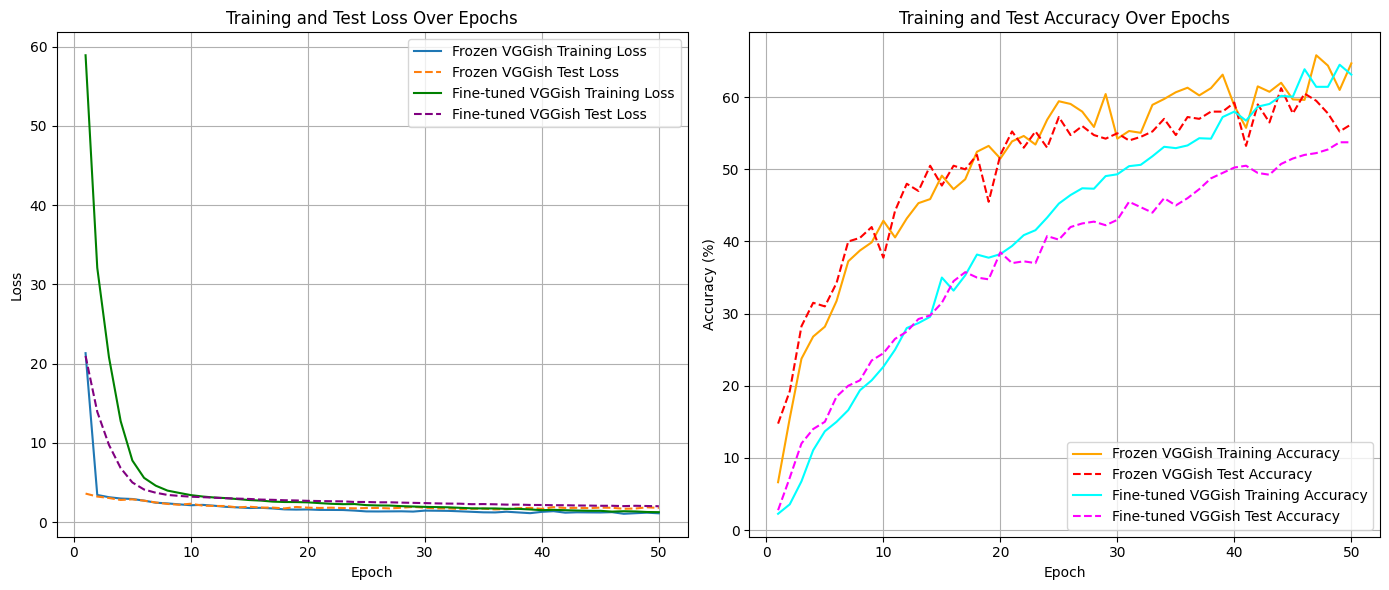

In [98]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), frozen_vggish_train_losses, label='Frozen VGGish Training Loss')
plt.plot(range(1, epochs + 1), frozen_vggish_test_losses, label='Frozen VGGish Test Loss', linestyle='--')
plt.plot(range(1, epochs + 1), finetuned_vggish_train_losses, label='Fine-tuned VGGish Training Loss', color='green')
plt.plot(range(1, epochs + 1), finetuned_vggish_test_losses, label='Fine-tuned VGGish Test Loss', linestyle='--', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), frozen_vggish_train_accuracies, label='Frozen VGGish Training Accuracy', color='orange')
plt.plot(range(1, epochs + 1), frozen_vggish_test_accuracies, label='Frozen VGGish Test Accuracy', linestyle='--', color='red')
plt.plot(range(1, epochs + 1), finetuned_vggish_train_accuracies, label='Fine-tuned VGGish Training Accuracy', color='cyan')
plt.plot(range(1, epochs + 1), finetuned_vggish_test_accuracies, label='Fine-tuned VGGish Test Accuracy', linestyle='--', color='magenta')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()

# Save the plot BEFORE showing it
plots_path = os.path.join(OUTPUT_DIR, 'combined_training_test_metrics.png')
plt.savefig(plots_path)
print(f'Combined training and test metrics plot saved to {plots_path}')

plt.show()

Combined training and test metrics plot saved to /content/drive/MyDrive/5888_Project/results/Phase1_Baseline/combined_training_test_metrics_1fold_5fold.png


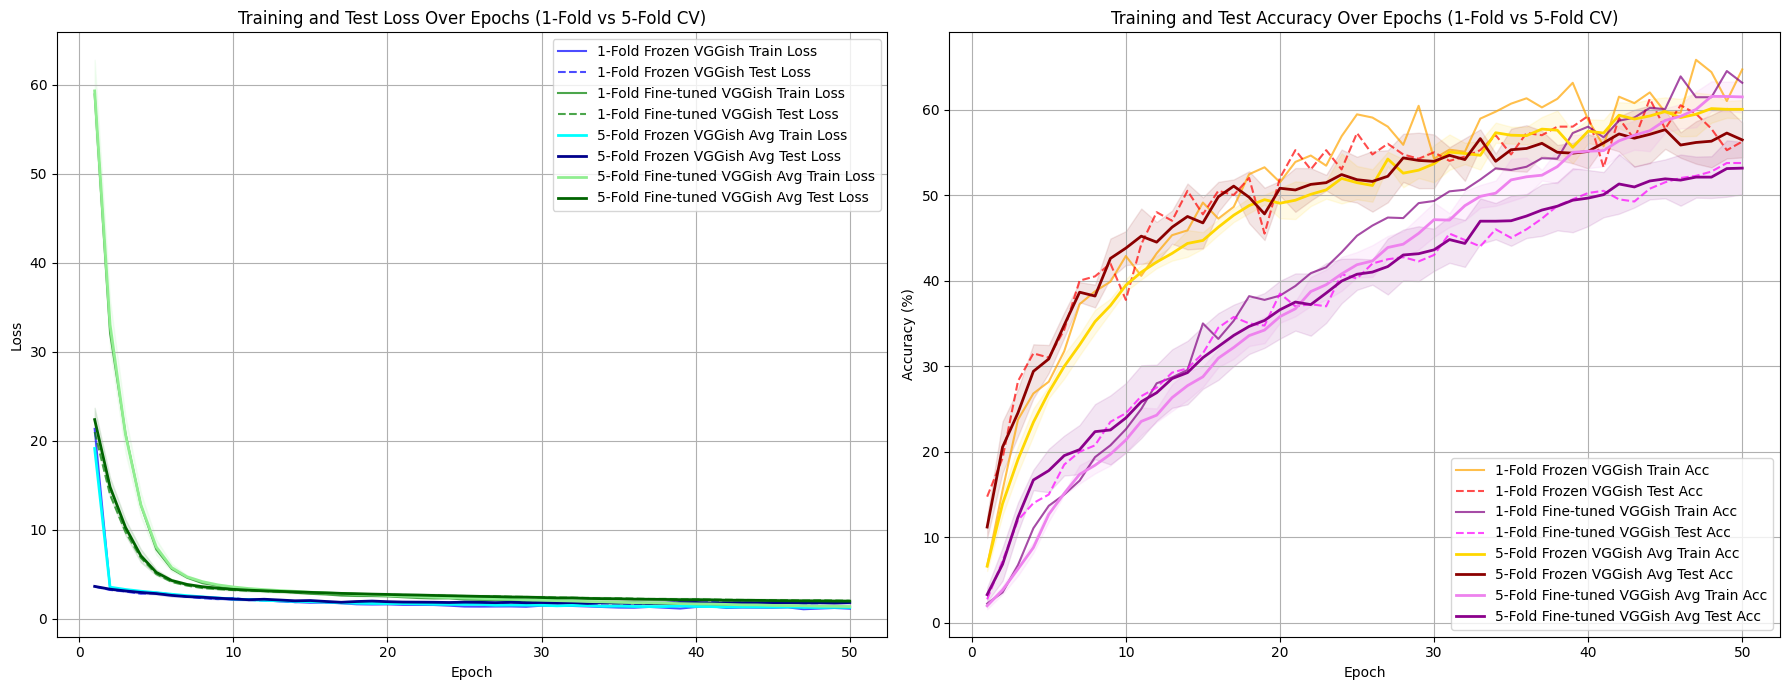

In [99]:
plt.figure(figsize=(18, 7))

# --- Loss Plot ---
plt.subplot(1, 2, 1)
# 1-fold results
plt.plot(range(1, epochs + 1), frozen_vggish_train_losses, label='1-Fold Frozen VGGish Train Loss', color='blue', alpha=0.7)
plt.plot(range(1, epochs + 1), frozen_vggish_test_losses, label='1-Fold Frozen VGGish Test Loss', color='blue', linestyle='--', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_vggish_train_losses, label='1-Fold Fine-tuned VGGish Train Loss', color='green', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_vggish_test_losses, label='1-Fold Fine-tuned VGGish Test Loss', color='green', linestyle='--', alpha=0.7)

# 5-fold cross-validation mean results with shaded standard deviation
plt.plot(range(1, epochs + 1), mean_frozen_vggish_train_losses, label='5-Fold Frozen VGGish Avg Train Loss', color='cyan', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_vggish_train_losses - std_frozen_vggish_train_losses, mean_frozen_vggish_train_losses + std_frozen_vggish_train_losses, color='cyan', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_frozen_vggish_test_losses, label='5-Fold Frozen VGGish Avg Test Loss', color='darkblue', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_vggish_test_losses - std_frozen_vggish_test_losses, mean_frozen_vggish_test_losses + std_frozen_vggish_test_losses, color='darkblue', alpha=0.1)

plt.plot(range(1, epochs + 1), mean_finetuned_vggish_train_losses, label='5-Fold Fine-tuned VGGish Avg Train Loss', color='lightgreen', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_vggish_train_losses - std_finetuned_vggish_train_losses, mean_finetuned_vggish_train_losses + std_finetuned_vggish_train_losses, color='lightgreen', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_finetuned_vggish_test_losses, label='5-Fold Fine-tuned VGGish Avg Test Loss', color='darkgreen', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_vggish_test_losses - std_finetuned_vggish_test_losses, mean_finetuned_vggish_test_losses + std_finetuned_vggish_test_losses, color='darkgreen', alpha=0.1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Over Epochs (1-Fold vs 5-Fold CV)')
plt.legend()
plt.grid(True)

# --- Accuracy Plot ---
plt.subplot(1, 2, 2)
# 1-fold results
plt.plot(range(1, epochs + 1), frozen_vggish_train_accuracies, label='1-Fold Frozen VGGish Train Acc', color='orange', alpha=0.7)
plt.plot(range(1, epochs + 1), frozen_vggish_test_accuracies, label='1-Fold Frozen VGGish Test Acc', color='red', linestyle='--', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_vggish_train_accuracies, label='1-Fold Fine-tuned VGGish Train Acc', color='purple', alpha=0.7)
plt.plot(range(1, epochs + 1), finetuned_vggish_test_accuracies, label='1-Fold Fine-tuned VGGish Test Acc', color='magenta', linestyle='--', alpha=0.7)

# 5-fold cross-validation mean results with shaded standard deviation
plt.plot(range(1, epochs + 1), mean_frozen_vggish_train_accuracies, label='5-Fold Frozen VGGish Avg Train Acc', color='gold', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_vggish_train_accuracies - std_frozen_vggish_train_accuracies, mean_frozen_vggish_train_accuracies + std_frozen_vggish_train_accuracies, color='gold', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_frozen_vggish_test_accuracies, label='5-Fold Frozen VGGish Avg Test Acc', color='darkred', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_frozen_vggish_test_accuracies - std_frozen_vggish_test_accuracies, mean_frozen_vggish_test_accuracies + std_frozen_vggish_test_accuracies, color='darkred', alpha=0.1)

plt.plot(range(1, epochs + 1), mean_finetuned_vggish_train_accuracies, label='5-Fold Fine-tuned VGGish Avg Train Acc', color='violet', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_vggish_train_accuracies - std_finetuned_vggish_train_accuracies, mean_finetuned_vggish_train_accuracies + std_finetuned_vggish_train_accuracies, color='violet', alpha=0.1)
plt.plot(range(1, epochs + 1), mean_finetuned_vggish_test_accuracies, label='5-Fold Fine-tuned VGGish Avg Test Acc', color='darkmagenta', linestyle='-', linewidth=2)
plt.fill_between(range(1, epochs + 1), mean_finetuned_vggish_test_accuracies - std_finetuned_vggish_test_accuracies, mean_finetuned_vggish_test_accuracies + std_finetuned_vggish_test_accuracies, color='darkmagenta', alpha=0.1)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy Over Epochs (1-Fold vs 5-Fold CV)')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()

# Save the plot BEFORE showing it
plots_path = os.path.join(OUTPUT_DIR, 'combined_training_test_metrics_1fold_5fold.png')
plt.savefig(plots_path)
print(f'Combined training and test metrics plot saved to {plots_path}')

plt.show()